In [1]:
from utils import get_data_tensors, evaluate_model, save_results, save_training_history, plot_training_history, compute_multiclass_roc, plot_multiclass_roc
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np


dataset_path = 'dataset/mnist_8x8.npz'
class_to_keep = [0, 1]
batch_size = 32


X_train, X_test, X_val, y_train, y_test, y_val, class_names = get_data_tensors(dataset_path, class_to_keep)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"Data loaded: {X_train.shape[0]} training samples, {X_val.shape[0]} validation samples, {X_test.shape[0]} test samples.")




n_qubits = 6  # 2^6 = 8x8
n_layers = 4 
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AmplitudeEmbedding(features=inputs, wires=range(n_qubits), normalize=True, pad_with=0.)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

Data loaded: 1400 training samples, 300 validation samples, 300 test samples.


In [2]:
n_qubits = int(np.ceil(np.log2(np.prod([8, 8]))))
n_qubits

6

c:\Users\Samy\Documents\UDES\Session 6\IFQ701\IFT701-Project\.venv\Lib\site-packages\pennylane\workflow\construct_batch.py:418: PennyLaneDeprecationWarning: Using `level=None` is deprecated and will be removed in a future release. Please use `level='device'` to include all transforms.
  _validate_level(level)


(<Figure size 3200x700 with 1 Axes>, <Axes: >)

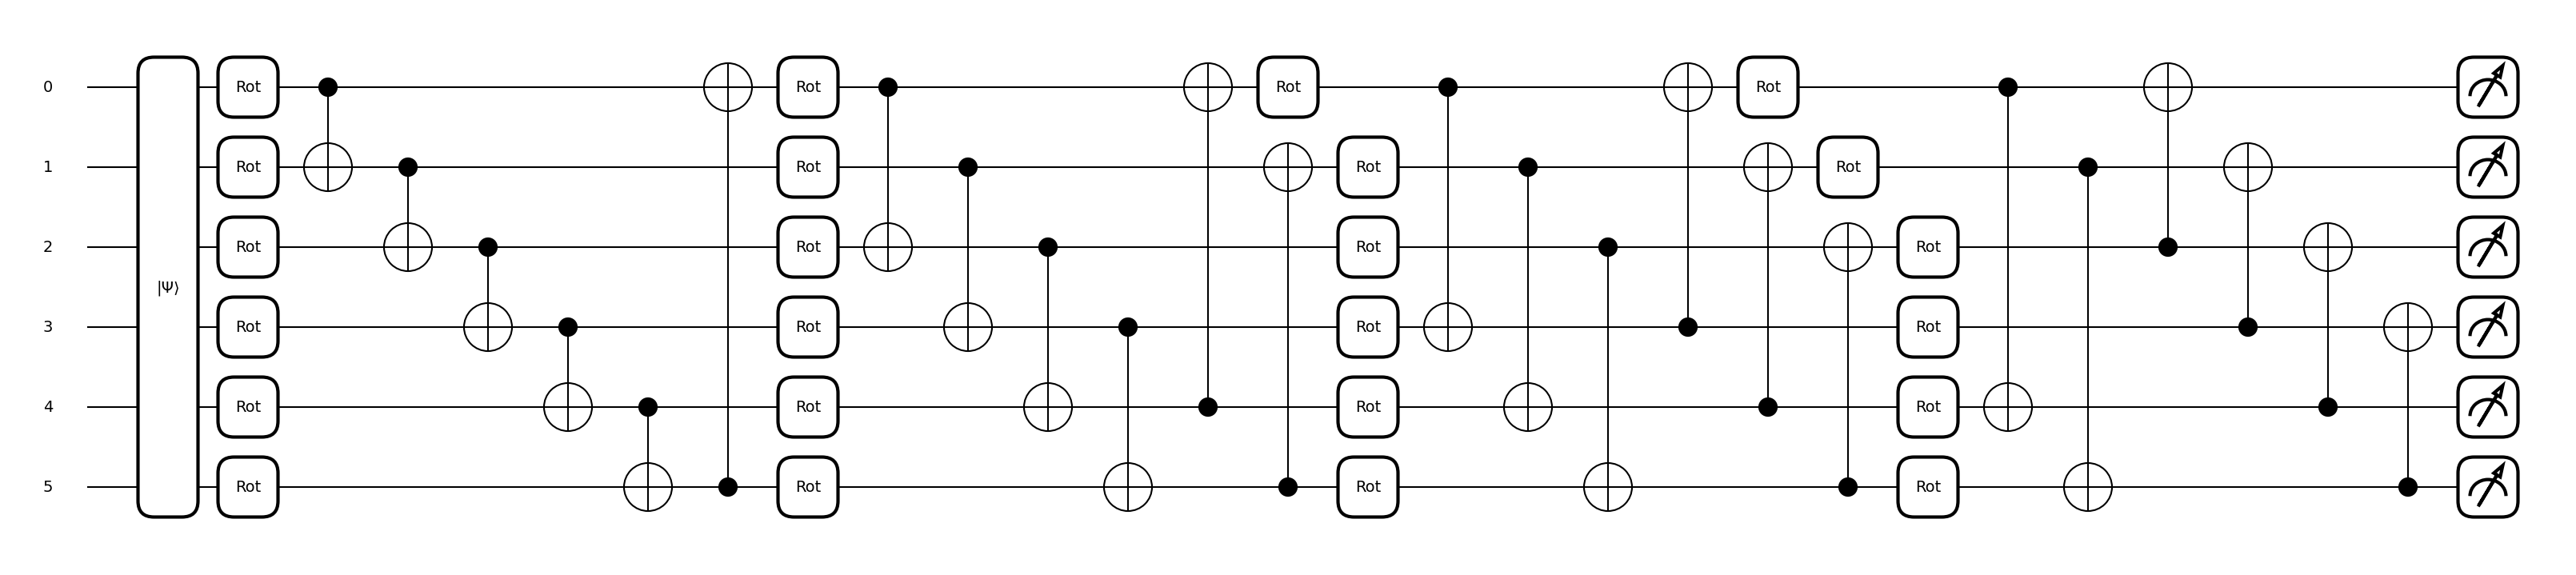

In [3]:
# Draw the circuit with mpl
qml.draw_mpl(quantum_circuit, level=None)(X_test[0].flatten(), torch.zeros((n_layers, n_qubits, 3)))

In [4]:
import numpy as np
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np



def quantum_pooling(control, target, weights):
    qml.U3(*weights[0:3], wires=control)
    qml.U3(*weights[0:3], wires=target)
    qml.CRot(*weights[6:9], wires=[control, target])


def quantum_convolution(control, target, weights):
    qml.U3(*weights[0:3], wires=control)
    qml.U3(*weights[3:6], wires=target)
    qml.CNOT(wires=[control, target])


n_qubits = int(np.ceil(np.log2(np.prod([8, 8]))))

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev, interface="torch") #Add diff_method="parameter-shift" for more realistic but much slower
def quantum_circuit(inputs, weights):
    qml.AmplitudeEmbedding(features=inputs, wires=range(n_qubits), normalize=True, pad_with=0.)
    qubits_left = list(range(n_qubits))
    param_idx = 0
    while len(qubits_left) > 1:
        n_active = len(qubits_left)
        for i in range(0, n_active-1, 2):
            quantum_convolution(qubits_left[i], qubits_left[(i+1)%n_active], weights[param_idx:param_idx+12])
            param_idx += 6
        for i in range(1, n_active-1, 2):
            quantum_convolution(qubits_left[i], qubits_left[(i+1)%n_active], weights[param_idx:param_idx+6])
            param_idx += 6
        
        new_qubits_left = []
        for i in range(0, n_active-1, 2):
            quantum_pooling(qubits_left[i], qubits_left[i+1], weights[param_idx:param_idx+9])
            param_idx += 9
            new_qubits_left.append(qubits_left[i+1])
        if n_active % 2 == 1:
            new_qubits_left.append(qubits_left[-1])
        qubits_left = new_qubits_left
        
    return [qml.expval(qml.PauliZ(i)) for i in qubits_left]

In [5]:
def get_param_count(n_qubits):
    total_params = 0
    active_qubits = n_qubits
    while active_qubits > 1:
        total_params += 6 * (active_qubits//2 + (active_qubits-1)//2)
        n_pools = active_qubits // 2
        total_params += n_pools * 9
        active_qubits = active_qubits - n_pools
    return total_params

params_needed = get_param_count(6)
print(f"Paramètres nécessaires pour 6 qubits : {params_needed}")

Paramètres nécessaires pour 6 qubits : 93


(<Figure size 2000x700 with 1 Axes>, <Axes: >)

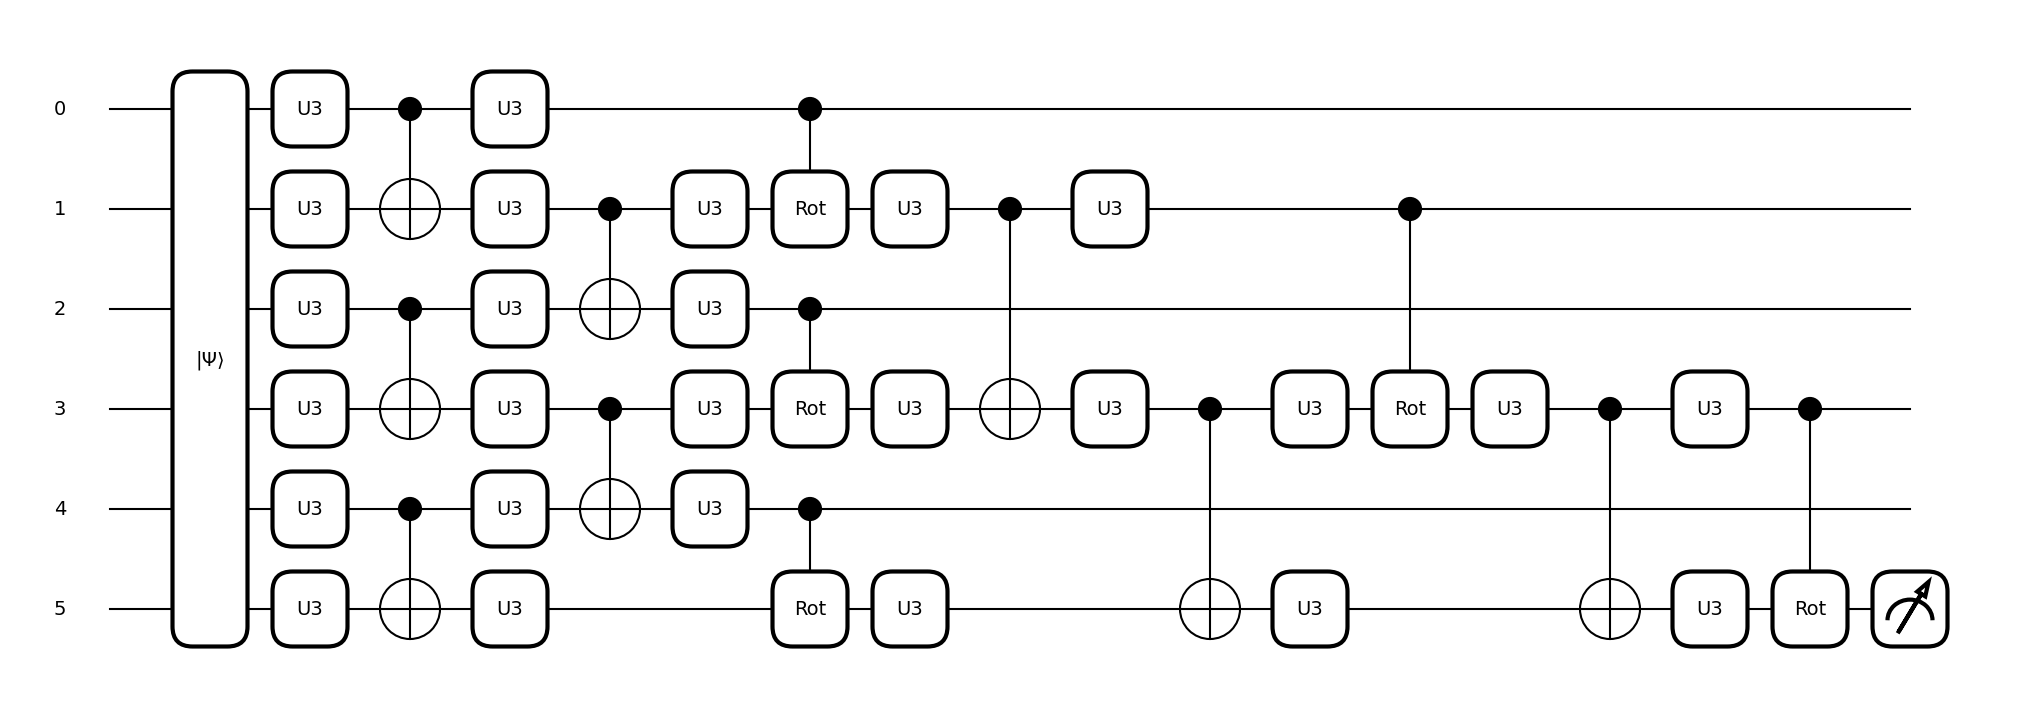

In [6]:
weights = torch.zeros(params_needed, requires_grad=True)
qml.draw_mpl(quantum_circuit)(X_test[0].flatten(), weights)